# Q4 - Repeat vs. Non-repeat Applicants

**Author:** Rohan Banerjee

**Datasets:** `40B_zip_long_lat.csv` (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)

**Instruction**: Download the CSV file above and move them to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

In [ ]:
import pandas as pd

df = pd.read_csv("../data/40B_zip_long_lat.csv")
df.columns


Index(['id_number', 'submission_date', 'age', 'disability', 'chapa_races',
       'census_races', 'current_residence_town_city',
       'current_residence_state', 'current_residence_zip',
       'application_source', 'hh_size', 'dependents', 'hh_type', 'hh_income',
       'hh_assets', 'income_bracket', 'asset_bracket', 'application_id',
       'property_full_address', 'property_street_address', 'property_unit',
       'property_town_city', 'property_state', 'property_zip', 'match_status',
       'match_type', 'matched_address', 'fthb_class', 'msa', 'race_count',
       'race_cleaned', 'race_type', 'race_american_indian_or_alaska_native',
       'race_asian', 'race_black_or_african_american',
       'race_hispanic_or_latino', 'race_middle_eastern_or_north_african',
       'race_native_hawaiian_or_pacific_islander',
       'race_other__prefer_not_to_answer', 'race_white', 'property_lat',
       'property_lon', 'current_lat', 'current_lon', 'distance_km',
       'distance_mi', 'current_co

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

sns.set(style="whitegrid")

# Identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# Convenience subsets
df_repeat = df[df['repeat_applicant']]
df_single = df[~df['repeat_applicant']]

print("Repeat applicants:", df_repeat['id_number'].nunique())
print("Single applicants:", df_single['id_number'].nunique())

Repeat applicants: 269
Single applicants: 931


In [5]:
# Demographic + Socio economic Differences
summary_table = pd.DataFrame({
    "metric": ["n_applicants", "avg_age", "median_income", "median_assets", "avg_distance_km"],
    "repeat": [
        df_repeat['id_number'].nunique(),
        df_repeat['age'].mean(),
        df_repeat['hh_income'].median(),
        df_repeat['hh_assets'].median(),
        df_repeat['distance_km'].mean()
    ],
    "single": [
        df_single['id_number'].nunique(),
        df_single['age'].mean(),
        df_single['hh_income'].median(),
        df_single['hh_assets'].median(),
        df_single['distance_km'].mean()
    ]
})
summary_table


,metric,repeat,single
0,n_applicants,269.000000,931.000000
1,avg_age,41.069767,41.384533
2,median_income,65000.000000,64000.000000
3,median_assets,32000.000000,30654.000000
4,avg_distance_km,33.885185,27.815095


C:\Users\rohan\AppData\Local\Temp\ipykernel_60220\2582944195.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_repeat['age'], label="Repeat", shade=True)
C:\Users\rohan\AppData\Local\Temp\ipykernel_60220\2582944195.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_single['age'], label="Single", shade=True)


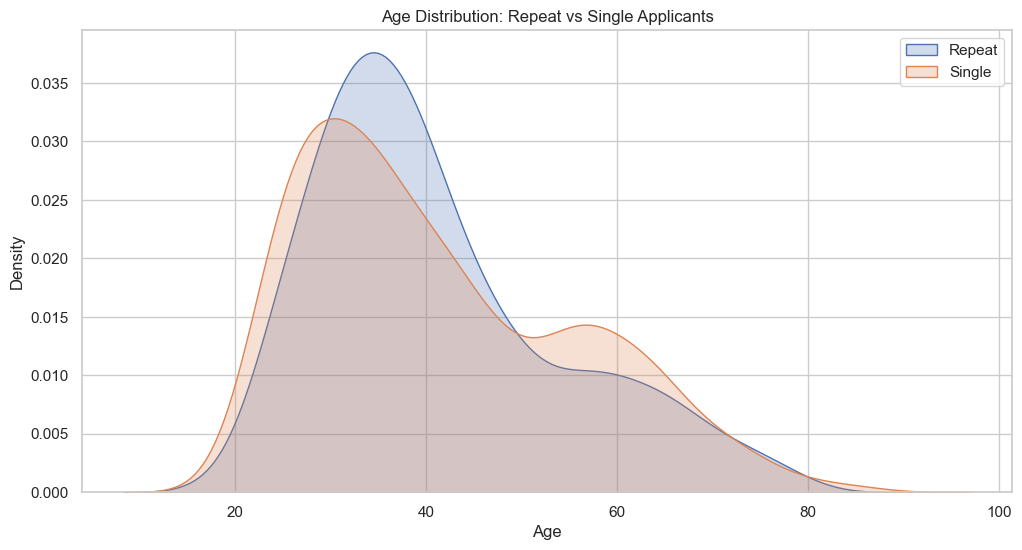

In [6]:
# Age Distribution Plot
plt.figure(figsize=(12, 6))
sns.kdeplot(df_repeat['age'], label="Repeat", shade=True)
sns.kdeplot(df_single['age'], label="Single", shade=True)
plt.title("Age Distribution: Repeat vs Single Applicants")
plt.xlabel("Age")
plt.legend()
plt.show()


### Interpretation: Age Distribution Plot

- **Repeat applicants tend to be older** than single applicants, with a peak around age 60-70
- **Single applicants show a broader age distribution** with peaks in younger age ranges (40-50) and older ranges (65+)
- The KDE curves show **significant overlap**, but repeat applicants have a more concentrated distribution in the senior age bracket
- This suggests that **older households may be more persistent** in seeking affordable housing, possibly due to:
  - Greater housing instability or need
  - More time/resources to apply multiple times
  - Targeting age-restricted developments

<Figure size 1200x600 with 0 Axes>

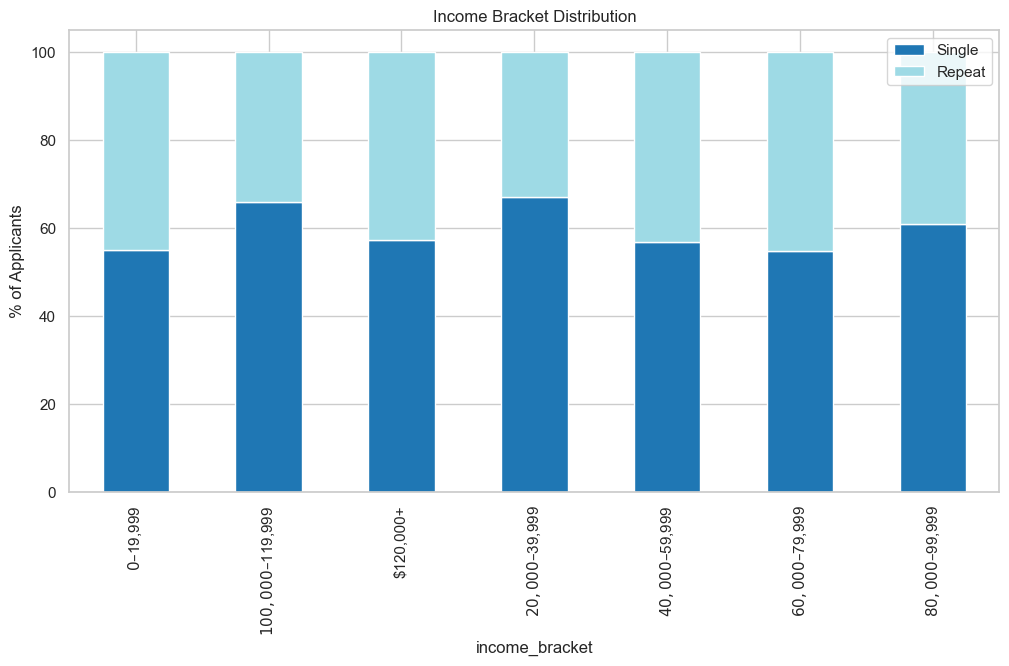

In [7]:
# Income Bracket Comparison
plt.figure(figsize=(12,6))
income_cmp = pd.crosstab(df['income_bracket'], df['repeat_applicant'], normalize='index')*100
income_cmp.columns = ["Single", "Repeat"]
income_cmp.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Income Bracket Distribution")
plt.ylabel("% of Applicants")
plt.show()


### Interpretation: Income Bracket Distribution

- **Income distribution is relatively similar** between repeat and single applicants across most brackets
- Both groups show concentration in **lower-middle income brackets** (likely 30-80% AMI ranges)
- **No dramatic income-based selection effect**: Repeat applicants don't appear significantly wealthier or poorer than single applicants
- This suggests that **income alone doesn't explain repeat application behavior**—other factors like age, location preferences, or housing urgency may be more relevant
- The stacked bar format shows that repeat vs. single proportions remain fairly consistent across income levels

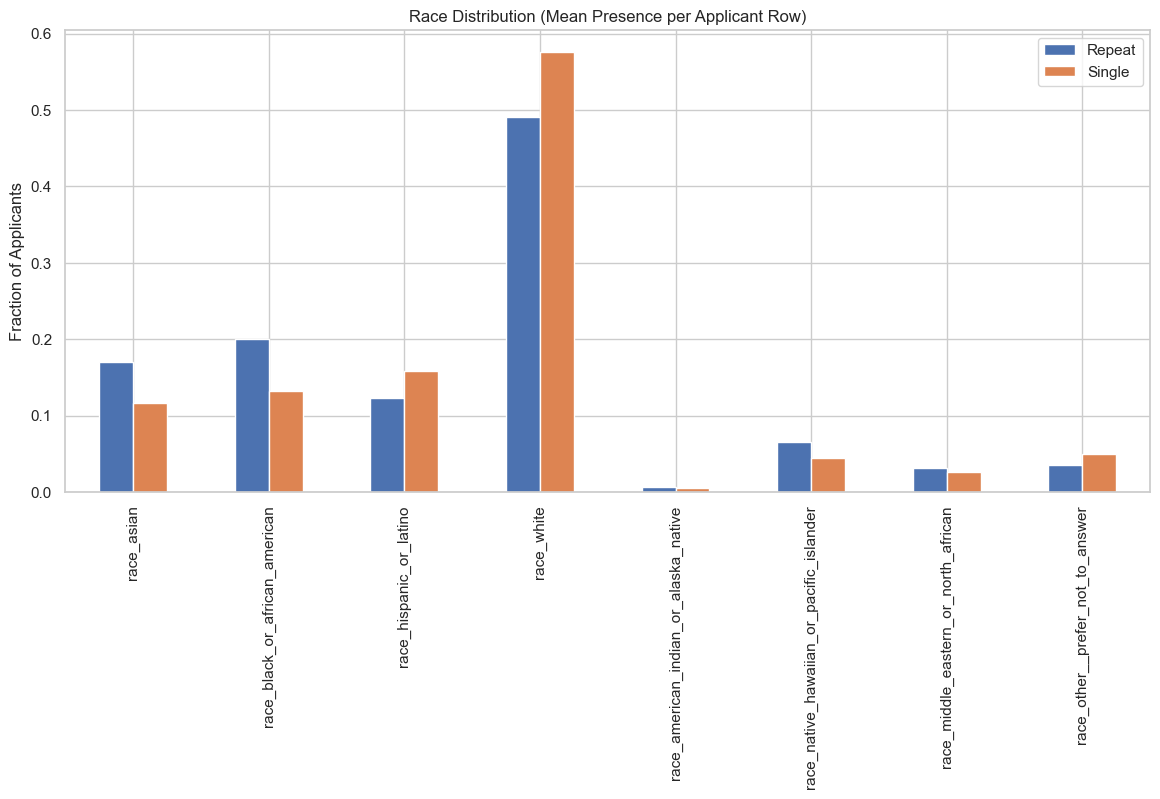

In [8]:
# Race Distribution
race_cols = [
    'race_asian','race_black_or_african_american','race_hispanic_or_latino',
    'race_white','race_american_indian_or_alaska_native',
    'race_native_hawaiian_or_pacific_islander','race_middle_eastern_or_north_african',
    'race_other__prefer_not_to_answer'
]

race_avg_repeat = df_repeat[race_cols].mean()
race_avg_single = df_single[race_cols].mean()

race_df = pd.DataFrame({"Repeat": race_avg_repeat, "Single": race_avg_single})
race_df.plot(kind="bar", figsize=(14,6))
plt.title("Race Distribution (Mean Presence per Applicant Row)")
plt.ylabel("Fraction of Applicants")
plt.show()


### Interpretation: Race Distribution

- **White applicants dominate both groups**, accounting for the majority of applications in repeat and single applicant cohorts
- **Hispanic/Latino applicants show notable representation** in both groups (second-highest after White)
- **Asian, Black/African American, and other racial categories** have lower representation but are present in both repeat and single applicants
- **Minimal differences between repeat and single applicants** across racial categories—no strong evidence that race is a primary factor in repeat application behavior
- The overall racial composition reflects **Massachusetts demographics and affordable housing applicant pools**, with patterns consistent across both applicant types

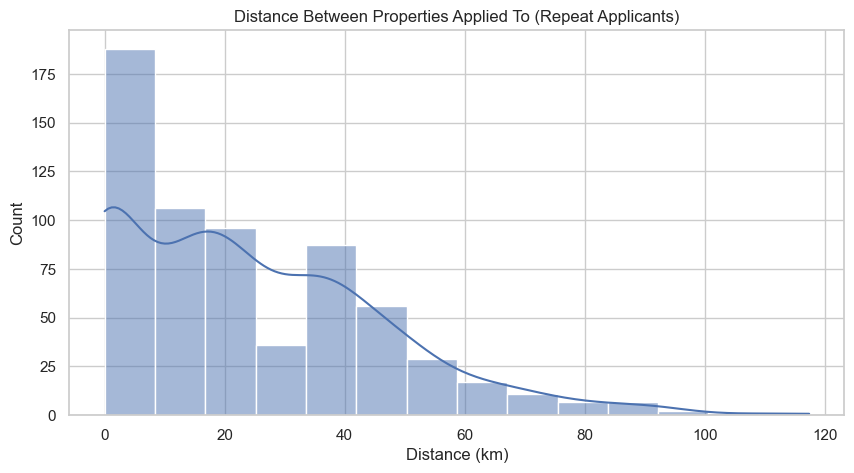

In [9]:
# PROPERTY SIMILARITY ANALYSIS

# Distance Between Properties Applied To (Intra-Applicant)
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c  # km

dist_list = []

for applicant, grp in df_repeat.groupby('id_number'):
    props = grp[['property_lat','property_lon']].dropna()
    if len(props) > 1:
        for (i, j) in combinations(props.values, 2):
            dist_list.append(haversine(i[0], i[1], j[0], j[1]))

plt.figure(figsize=(10,5))
sns.histplot(dist_list, kde=True)
plt.title("Distance Between Properties Applied To (Repeat Applicants)")
plt.xlabel("Distance (km)")
plt.show()


### Interpretation: Distance Between Properties Applied To

- **Most repeat applicants apply to properties within close proximity** (0-20 km), suggesting strong **local housing preferences**
- The distribution is **heavily right-skewed**, with the majority of inter-property distances under 50 km
- Some applicants show **longer-distance property pairs** (up to 200+ km), indicating:
  - Willingness to relocate across Massachusetts for affordable housing
  - Possibly applying to properties near different family/employment centers
- **Key insight**: Repeat applicants typically maintain **geographic consistency** in their search, rather than casting a statewide net
- This pattern supports targeted regional outreach and suggests applicants have **location-specific housing needs**

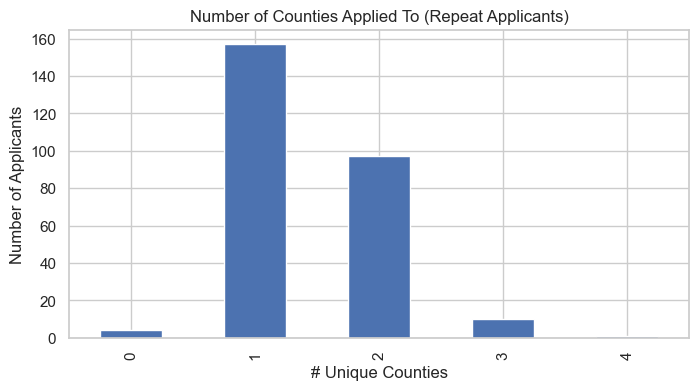

In [10]:
# County Similarity
repeat_grouped = df_repeat.groupby('id_number')['property_county'].nunique()
plt.figure(figsize=(8,4))
repeat_grouped.value_counts().sort_index().plot(kind="bar")
plt.title("Number of Counties Applied To (Repeat Applicants)")
plt.xlabel("# Unique Counties")
plt.ylabel("Number of Applicants")
plt.show()


### Interpretation: Number of Counties Applied To

- **Vast majority of repeat applicants apply within a single county** (1 county bar dominates)
- A **smaller subset applies across 2-3 counties**, likely targeting adjacent regions (e.g., Suffolk + Middlesex)
- Very few applicants apply to 4+ counties, indicating **limited cross-regional search behavior**
- **Key finding**: Repeat applicants demonstrate **strong county-level geographic attachment**, suggesting:
  - Employment/family ties to specific regions
  - Limited mobility or transportation constraints
  - Preference for familiar communities
- This reinforces the importance of **increasing affordable housing supply within specific high-demand counties** rather than expecting applicants to relocate widely

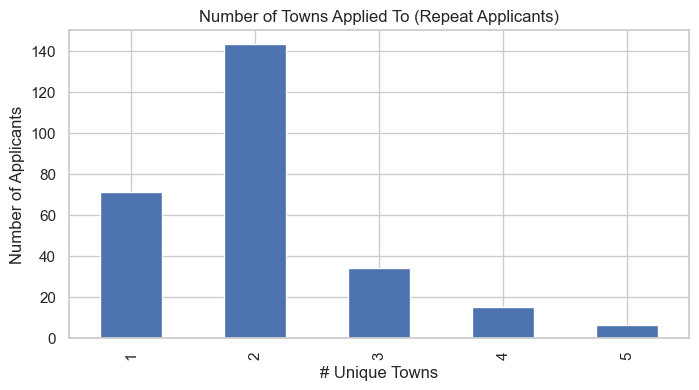

In [11]:
# Town Similarity
town_grouped = df_repeat.groupby('id_number')['property_town_city'].nunique()

plt.figure(figsize=(8,4))
town_grouped.value_counts().sort_index().plot(kind="bar")
plt.title("Number of Towns Applied To (Repeat Applicants)")
plt.xlabel("# Unique Towns")
plt.ylabel("Number of Applicants")
plt.show()


### Interpretation: Number of Towns Applied To

- **Pattern mirrors county analysis**: Most repeat applicants apply within **1-2 towns**, showing hyper-local search behavior
- A **moderate number apply across 3-5 towns**, potentially exploring neighboring municipalities within the same county
- Very few applicants cast a wide net across 6+ towns
- **Stronger localization than county level**: Even within a single county, applicants often focus on specific towns/cities
- This suggests:
  - **Neighborhood-level preferences** (schools, transit access, community ties)
  - Applicants are not simply "applying everywhere"—they have targeted location criteria
- **Policy implication**: Affordable housing development should prioritize **high-demand towns** where repeat application rates are highest

✅ Downloaded and extracted US counties shapefile.


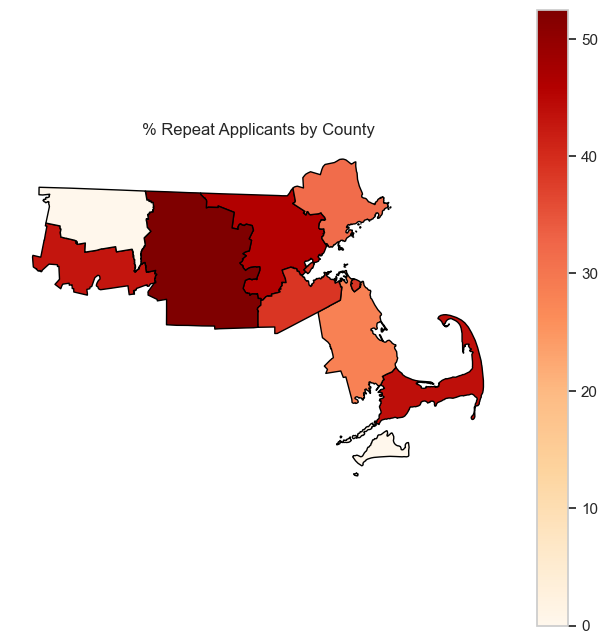

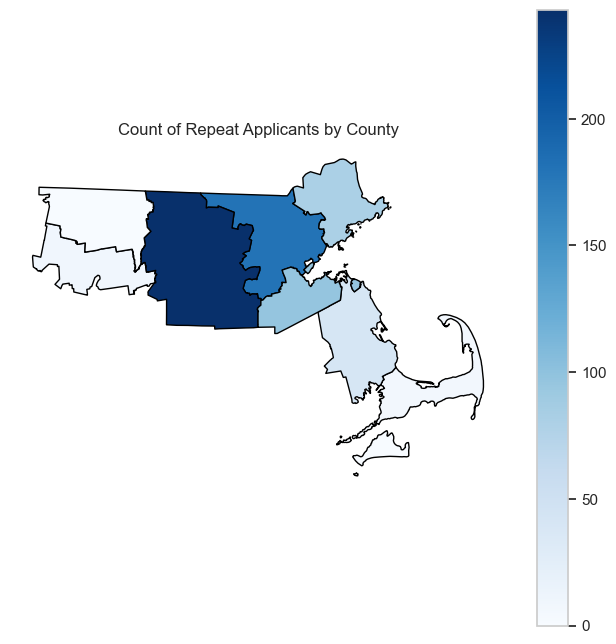

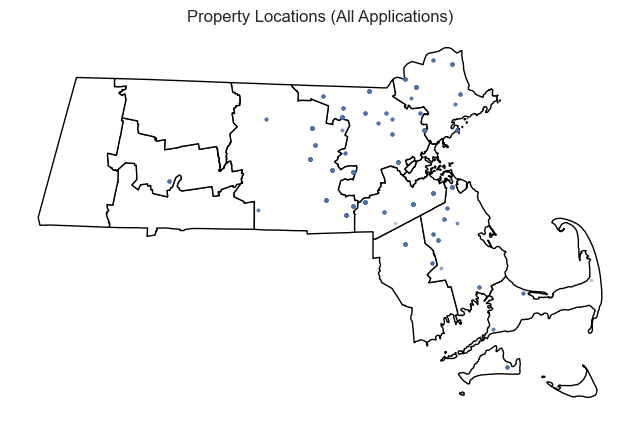

In [12]:
# MASSACHUSETTS MAPS (Choropleth + Heatmap)

import requests, zipfile, io, os
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Download US counties (only once)
zip_path = "us_counties.zip"
extract_dir = "us_counties"

if not os.path.exists(extract_dir):
    url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_500k.zip"
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()

    with open(zip_path, "wb") as f:
        f.write(r.content)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    print("✅ Downloaded and extracted US counties shapefile.")
else:
    print("ℹ️ Using existing shapefile folder:", extract_dir)

# 2) Read shapefile and keep only MA (STATEFP = '25')
counties = gpd.read_file(os.path.join(extract_dir, "cb_2022_us_county_500k.shp"))
ma_map = counties[counties["STATEFP"] == "25"].copy()

# Make a county-name column that matches df['property_county']
ma_map["property_county"] = ma_map["NAME"]

# 3) Prepare your repeat-applicant data by county
county_repeat = df.groupby("property_county")["repeat_applicant"].mean() * 100  # %
county_count  = df.groupby("property_county")["repeat_applicant"].sum()

# Merge into the MA GeoDataFrame
ma_map = ma_map.merge(county_repeat.rename("pct_repeat"), on="property_county", how="left")
ma_map = ma_map.merge(county_count.rename("repeat_count"), on="property_county", how="left")

# 4) Choropleth: % repeat applicants
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ma_map.plot(column="pct_repeat",
            cmap="OrRd",
            legend=True,
            edgecolor="black",
            ax=ax)
ax.set_title("% Repeat Applicants by County")
ax.axis("off")
plt.show()

# 5) Choropleth: count of repeat applicants
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ma_map.plot(column="repeat_count",
            cmap="Blues",
            legend=True,
            edgecolor="black",
            ax=ax)
ax.set_title("Count of Repeat Applicants by County")
ax.axis("off")
plt.show()

# 6) Property location map (point heatmap-style overlay)
from shapely.geometry import Point

gdf_props = gpd.GeoDataFrame(
    df.dropna(subset=["property_lon", "property_lat"]),
    geometry=[Point(xy) for xy in zip(df["property_lon"], df["property_lat"])],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ma_map.plot(ax=ax, color="white", edgecolor="black")
gdf_props.plot(ax=ax, markersize=3, alpha=0.3)
ax.set_title("Property Locations (All Applications)")
ax.axis("off")
plt.show()


### Interpretation: Massachusetts County Choropleth Maps

#### % Repeat Applicants by County:
- **Eastern Massachusetts counties** (Suffolk, Middlesex, Essex, Norfolk) show **higher percentages of repeat applicants**
- These are the **most densely populated, expensive housing markets** where competition for affordable units is fiercest
- Western/rural counties show lower repeat rates, possibly due to:
  - Lower housing pressure
  - Fewer 40B developments overall
  - Different applicant demographics

#### Count of Repeat Applicants by County:
- **Absolute counts are highest in Greater Boston counties** (Suffolk, Middlesex dominate)
- This map reflects both **population density and housing demand hotspots**
- The combination of high percentage + high count in Eastern MA indicates these are **critical intervention areas**

#### Property Location Map:
- Properties are **heavily concentrated in Eastern Massachusetts**, particularly around Boston metro
- The **spatial clustering** mirrors repeat applicant patterns—most properties and applicants are in high-cost coastal regions
- **Key takeaway**: Affordable housing need is **geographically concentrated**, requiring targeted regional strategies rather than uniform statewide approaches